<a href="https://colab.research.google.com/github/ahmer-talal/AI-Labs/blob/main/BFS_LabTasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Lab Tasks of Breadth First Search**
## **Ahmer Talal**
## **SP23-BCS-041**

## **Task 1:** Imagine going from ***Arad*** to ***Bucharest*** in the following map. Implement a BFS to find the corresponding path.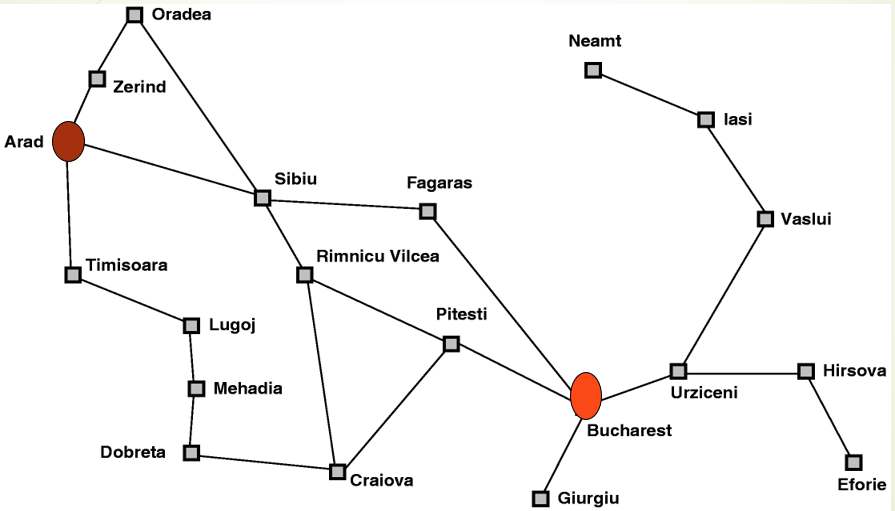

In [2]:
# Step 1: Defining the map in a dictionary format
romania_map = {
    'Arad': ['Zerind', 'Sibiu', 'Timisoara'],
    'Zerind': ['Arad', 'Oradea'],
    'Oradea': ['Zerind', 'Sibiu'],
    'Sibiu': ['Arad', 'Oradea', 'Fagaras', 'Rimnicu Vilcea'],
    'Timisoara': ['Arad', 'Lugoj'],
    'Lugoj': ['Timisoara', 'Mehadia'],
    'Mehadia': ['Lugoj', 'Drobeta'],
    'Drobeta': ['Mehadia', 'Craiova'],
    'Craiova': ['Drobeta', 'Rimnicu Vilcea', 'Pitesti'],
    'Rimnicu Vilcea': ['Sibiu', 'Craiova', 'Pitesti'],
    'Fagaras': ['Sibiu', 'Bucharest'],
    'Pitesti': ['Rimnicu Vilcea', 'Craiova', 'Bucharest'],
    'Bucharest': ['Fagaras', 'Pitesti', 'Giurgiu', 'Urziceni'],
    'Giurgiu': ['Bucharest'],
    'Urziceni': ['Bucharest', 'Hirsova', 'Vaslui'],
    'Hirsova': ['Urziceni', 'Eforie'],
    'Eforie': ['Hirsova'],
    'Vaslui': ['Urziceni', 'Iasi'],
    'Iasi': ['Vaslui', 'Neamt'],
    'Neamt': ['Iasi']
}

In [3]:
# Step 2: BFS Algorithm Implementation

def bfs_shortest_path(graph, start, goal):
    explored = []

    queue = [[start]] # Initialize queue with starting node

    if start == goal:
        return "Start node is the goal!"

    while queue:  # until queue is empty
        path = queue.pop(0)
        node = path[-1]

        if node not in explored:
            neighbors = graph[node]

            # Create a new path for each neighbor
            for neighbor in neighbors:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

                # If the neighbor is our goal, return the generated path
                if neighbor == goal:
                    return new_path

            # Mark the node as explored after checking all its neighbors
            explored.append(node)

    return "No path found"

In [6]:
# Step 3: Call BFS function & print result
start_node = 'Arad'
goal_node = 'Bucharest'

result_path = bfs_shortest_path(romania_map, start_node, goal_node)

print(f"Goal Reached!\nThe BFS path from {start_node} to {goal_node} is: \n{result_path}")

Goal Reached!
The BFS path from Arad to Bucharest is: 
['Arad', 'Sibiu', 'Fagaras', 'Bucharest']


## **Task 2:** Consider a maze as shown below. Each empty tile represents a separate node in the graph. There are  maximum of four possible actions i.e., to move up, down, left or right on any given tile/node. Using  ***BFS,*** find out how to get out of the maze if you’re in the start position depicted below. 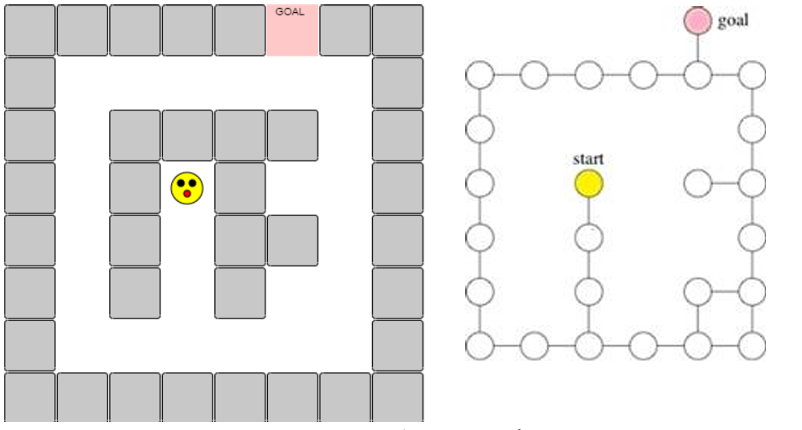

In [19]:
# Step 1: Mapping the given graph into a dictionary
# 'Start' and 'Goal' are explicitly named.
maze_graph = {
    'Start': ['N1'],
    'N1': ['Start', 'N2'],
    'N2': ['N1', 'N3'],
    'N3': ['N2', 'N4', 'N16'], # Junction splitting left and right

    # Left Path (Leading towards the Goal)
    'N4': ['N3', 'N5'],
    'N5': ['N4', 'N6'],
    'N6': ['N5', 'N7'],        # Bottom-Left corner
    'N7': ['N6', 'N8'],
    'N8': ['N7', 'N9'],
    'N9': ['N8', 'N10'],
    'N10': ['N9', 'N11'],      # Top-Left corner
    'N11': ['N10', 'N12'],
    'N12': ['N11', 'N13'],
    'N13': ['N12', 'N14'],
    'N14': ['N13', 'Goal', 'N15'],
    'Goal': ['N14'],

    # Top-Right Path (Dead End)
    'N15': ['N14', 'N21'],     # Top-Right corner
    'N21': ['N15'],            # Dead end going down

    # Right Path from Junction (N3) & The Square Loop
    'N16': ['N3', 'N17', 'N20'],
    'N17': ['N16', 'N18'],
    'N18': ['N17', 'N19'],
    'N19': ['N18', 'N20'],
    'N20': ['N19', 'N16']      # Completes the square loop
}

In [20]:
# Step 2: BFS Algorithm
def bfs_maze_solver(graph, start, goal):
    explored = []
    queue = [[start]]

    if start == goal:
        return "Start node is the goal!"

    while queue:
        path = queue.pop(0)
        node = path[-1]

        if node not in explored:
            # Get neighbors, default to empty list if node not found
            neighbors = graph.get(node, [])

            for neighbor in neighbors:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

                # If found the Goal, return the path
                if neighbor == goal:
                    return new_path

            # Mark node as explored
            explored.append(node)

    return "No path found out of the maze."

In [21]:
# Step 3: Run the code & print the result
result_path = bfs_maze_solver(maze_graph, 'Start', 'Goal')

print(f"Goal Reached!\nThe BFS path to get out of the maze is: \n{result_path}")

Goal Reached!
The BFS path to get out of the maze is: 
['Start', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'N11', 'N12', 'N13', 'N14', 'Goal']
